### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path

BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/consumer_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/consumer_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [3]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [16]:
Industry_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Consumer Economy",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
Industry_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
385,265_0_0_0_0,https://www.bizcommunity.com/Article/196/778/2...,2023-11-22,#Trends: DMOs embrace AI and prioritise digita...,72,#Trends: DMOs embrace AI and prioritise digita...
699,511_1_0_0_0,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,49,Email Address\n *5#000000#FFFFFFHOME>News>arti...


In [5]:
print(len(Industry_chunks))

3426


### Bertopic

In [8]:
# ! pip install bertopic

In [11]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small" , device="cuda")

umap_model = UMAP(
    n_neighbors=50, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=15, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

# 100,20
hdbscan_model = HDBSCAN(
    min_cluster_size=200, # smaller min_cluster_size will -> more detailed topics
    min_samples=50, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
docs = Industry_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [13]:
Content_topics = topic_model.get_topic_info()
Industry_chunks_topics = Industry_chunks.assign( topic=topics,  probability=probs)

In [14]:
show_full(Content_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,0,"[shopify, retail market, retailer, intelligence retail, in-store, shopping experience, online shopping, shopper, shopping experiences, retail industry]",1338
1,1,"[drive-thru, wendy, cooking, fast food, taco, grill, chipotle, taco bell, drive-thrus, steak]",1064
2,2,"[expedia, itinerary, travel industry, travel planning, skift, travelingwiki, travellers, online travel, traveler, planner]",1024


In [15]:
Content_topics.to_csv(f"{DATA_DIR}/Content_specific/Content_topics.csv", index=False)
Industry_chunks_topics.to_parquet(f"{DATA_DIR}/Content_specific/Industry_chunks_topics.parquet", index=False)

### Sentiment Analysis on chunk level

In [3]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Content_specific/Industry_chunks_topics.parquet")

##### 1. use LLM to generate 100 labels

In [4]:
df_ai_impact['topic'].value_counts()    

topic
0    1338
1    1064
2    1024
Name: count, dtype: int64

In [5]:
def topic_sample_n(topic_size):
    if topic_size >= 1300:
        return 170
    elif topic_size >= 800:
        return 160

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

490


C:\Users\ss363\AppData\Local\Temp\ipykernel_35968\2127676678.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


topic
0    170
1    160
2    160
Name: count, dtype: int64

In [6]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [7]:
system_msg = """
You are an expert analyst of the Consumer Economy industries.

Your task is to evaluate the directional impact of AI or AI-related developments
on consumer-facing industries described in the text.

These industries include but are not limited to:

- retail (e-commerce platforms, brick-and-mortar retailers)
- food and restaurants (fast food chains, food delivery platforms, dining)
- travel and tourism (airlines, hotels, travel agencies, booking platforms)
- hospitality and leisure services
- supermarkets and grocery chains
- shopping platforms and marketplaces

You must classify the impact into EXACTLY ONE of the following:

1. "positively"

Definition:
The text suggests that AI or related technologies are expected to benefit
consumer-facing industries, companies, or service providers.

Examples include:
- improved customer experience through AI recommendations
- personalized marketing and product recommendations
- supply chain optimization
- demand forecasting improvements
- cost reduction through automation
- smarter pricing strategies
- improved logistics and inventory management
- AI-powered customer service or chatbots
- enhanced travel planning or booking systems
- operational efficiency in restaurants, hotels, or retail stores

2. "negatively"

Definition:
The text suggests that AI or related technologies are expected to harm,
disrupt, or create risks for consumer economy industries or workers.

Examples include:
- job displacement in retail, hospitality, or food service
- operational disruptions caused by AI systems
- unfair algorithmic pricing or consumer manipulation
- privacy concerns in personalized marketing
- increased competition due to AI-enabled platforms
- AI-driven market concentration disadvantaging smaller businesses
- consumer trust issues due to AI decisions
- over-automation harming service quality

3. "hard-to-say"

Definition:
The text is neutral, mixed, uncertain, or descriptive without a clear
positive or negative direction.

Examples include:
- both benefits and risks are discussed without a dominant direction
- the article explains AI technology used in retail or travel
  without evaluating its economic impact
- industry reactions or debates are described without clear conclusions
- the impact of AI on the consumer economy is speculative or unclear

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Evaluate impact specifically in the context of consumer economy industries.
- Consider effects on retailers, restaurants, travel companies, hotels,
  consumer brands, and customer-facing service providers.
- Do not over-interpret isolated optimistic or pessimistic phrases.
- If both positive and negative effects appear without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without a clear judgment,
  choose "hard-to-say".
- Ignore boilerplate text, navigation fragments, advertisements, or unrelated content.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly explain the evidence for the classification
  in the context of consumer economy industries.
"""

impact_user_template = """
Here is a text segment from the Consumer Economy domain:

{chunk_text}

Please determine whether AI is expected to impact the consumer economy
industry, companies, or services positively, negatively, or in an unclear/mixed way.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [8]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [9]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [10]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
# print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
positively     370
hard-to-say     86
negatively      34
Name: count, dtype: int64

lack negative labels

In [11]:
style_prompts = [
    "Write in the style of a mainstream business newspaper: concise, factual, professional, and market-aware.",
    "Write in the style of a retail industry publication: practical, sector-specific, and focused on store operations, merchandising, and customer behavior.",
    "Write in the style of a technology-business news site: focus on product adoption, disruption, and operational consequences.",
    "Write in the style of a global economic newswire: neutral, information-dense, and report-like.",
    "Write in the style of an investigative business publication: emphasize governance, regulatory concerns, consumer harm, and systemic risk.",
    "Write in the style of a hospitality and travel trade publication: practical, service-oriented, and focused on booking, staffing, and customer experience.",
    "Write in the style of a corporate risk and operations publication: focus on process failure, automation risk, fraud exposure, fulfillment breakdowns, and reputational damage.",
    "Write in the style of a long-form explanatory news site: accessible but serious, with clear causal explanation of negative effects."
]
import json
import pandas as pd
import openai
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

system_msg = """
You are a business news writer.

Generate realistic news-style text passages about the negative impacts of AI on the consumer economy.
Each passage should resemble a plausible article segment from a business, retail, travel, hospitality, or consumer industry news source.

Requirements:
- Focus on negative impacts of AI in consumer-facing industries
- These industries may include retail, e-commerce, food and restaurants, travel, tourism,
  hospitality, consumer brands, grocery, marketplaces, and customer service businesses
- Topics may include layoffs in retail, hospitality, food service, or travel;
  degraded customer service due to over-automation;
  inaccurate recommendations or personalization failures;
  pricing errors or unfair algorithmic pricing;
  demand forecasting mistakes leading to overstocking or shortages;
  supply chain disruption caused by faulty AI systems;
  reputational damage from biased, intrusive, or manipulative AI use;
  privacy concerns related to customer data collection and profiling;
  consumer backlash against AI-driven experiences replacing human service;
  operational failures in stores, restaurants, hotels, airlines, or booking platforms;
  platform advantage that harms smaller retailers, restaurants, or travel providers;
  margin pressure caused by AI-driven competition;
  misleading advertising or synthetic reviews/content;
  fraud, scams, or fake customer interactions enabled by AI;
  regulatory scrutiny around pricing, privacy, transparency, or consumer protection;
  job displacement of frontline, support, or service workers;
  accessibility or inclusion failures that harm certain customer groups;
  booking, fulfillment, or delivery errors caused by AI systems;
  or customer harm caused by incorrect automated decisions
- Use a neutral, journalistic tone
- Do not use bullet points
- Do not number items inside the text
- Each passage should be fully written prose, not a summary
- Each passage should be roughly 1200-1800 characters
- The 5 passages in one batch must differ clearly in structure and wording
- Use paragraph breaks with blank lines between paragraphs
- Return JSON only

Output format:
{
  "samples": [
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."}
  ]
}
"""

@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer_hightemp(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=1.1
    )
    return json.loads(completion.choices[0].message.content)

In [12]:
all_samples = []

for i, style in enumerate(style_prompts, start=1):
    user_msg = f"""
Generate 5 realistic news-style passages about the negative impact of AI on the consumer economy and consumer-facing industries.

Style instruction:
{style}

Additional instructions:
- The five passages should not repeat each other
- They should vary in angle, such as retail operations, e-commerce platforms, restaurants,
  grocery chains, travel booking systems, airlines, hotels, delivery platforms,
  customer service automation, pricing algorithms, supply chains, or consumer data use
- Avoid copying common template phrasing
- Make the set feel like it came from different article excerpts rather than one repeated template
- Vary the paragraph structure noticeably across the 5 passages
- Some passages should be relatively compact with 2-3 paragraphs
- Some passages should be moderately developed with 4-5 paragraphs
- At least one passage should be more fully developed with 5-6 paragraphs
- Do not make all 5 passages appear as a single block of text
- Use blank lines between paragraphs
- Focus on operational, economic, or consumer-facing consequences
- Keep the tone journalistic and realistic, similar to business or industry reporting
- Return JSON only
"""

    raw_result = get_answer_hightemp(
        client=client,
        system_msg=system_msg,
        user_msg=user_msg,
        model="deepseek-chat"
    )

    batch_df = pd.DataFrame(raw_result["samples"]).copy()
    batch_df["style_prompt"] = style
    all_samples.append(batch_df)

In [13]:
df_synth_negative = pd.concat(all_samples, ignore_index=True)

df_synth_negative["impact_label"] = "negatively"
df_synth_negative["api_status"] = "synthetic_negative"
df_synth_negative["topic"] = -999
df_synth_negative["chunk_uid"] = [f"synth_neg_{i}" for i in range(len(df_synth_negative))]

df_synth_negative = df_synth_negative[
    ["chunk_uid", "topic","chunk_text", "impact_label",  "api_status"]
].reset_index(drop=True)

print(df_synth_negative.shape)
df_synth_negative.head()

(40, 5)


,chunk_uid,topic,chunk_text,impact_label,api_status
0,synth_neg_0,-999,Major grocery chains are facing significant op...,negatively,synthetic_negative
1,synth_neg_1,-999,Hospitality operators are grappling with consu...,negatively,synthetic_negative
2,synth_neg_2,-999,E-commerce platforms are facing mounting regul...,negatively,synthetic_negative
3,synth_neg_3,-999,The restaurant industry is confronting an unex...,negatively,synthetic_negative
4,synth_neg_4,-999,Travel booking platforms are experiencing wide...,negatively,synthetic_negative


In [14]:
df_synth_negative["n_char"] = df_synth_negative["chunk_text"].str.len()
display(df_synth_negative["n_char"].describe())

df_train_ai_impact_label_aug = pd.concat(
    [df_train_ai_impact_label, df_synth_negative],
    ignore_index=True
)

df_train_ai_impact_label_aug["impact_label"].value_counts()

count      40.000000
mean     1541.475000
std       411.970499
min      1020.000000
25%      1229.500000
50%      1463.000000
75%      1699.750000
max      2470.000000
Name: n_char, dtype: float64

impact_label
positively     370
hard-to-say     86
negatively      74
Name: count, dtype: int64

In [19]:
df_train_ai_impact_label_aug.to_parquet(f"{DATA_DIR}/Content_specific/df_consumer_train_ai_impact_label_aug.parquet", index=False)

##### 2. finetune classifer

In [4]:
df_train_ai_impact_label = pd.read_parquet(f"{DATA_DIR}/Content_specific/df_consumer_train_ai_impact_label_aug.parquet")
display(df_train_ai_impact_label['impact_label'].value_counts())

,count
impact_label,
positively,370
hard-to-say,86
negatively,74


In [5]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label.loc[df_train_ai_impact_label["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,New Shopify and Google Cloud AI Integration Br...,2
1,"Additionally, the Developer Super Agent will s...",2
2,Walmart Plans To Grow Revenue Without Hiring M...,2
3,Retail owners using artificial intelligence to...,2
4,"Though people now can—and do—shop in person, t...",2


In [11]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.17, random_state=40, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
2    307
1     71
0     61
Name: count, dtype: int64
label
2    63
1    15
0    13
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 439
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 91
    })
})

In [12]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/439 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 439
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 91
    })
})

In [13]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "content_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [14]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.696481,0.692308,0.272727,0.230769,0.333333
2,0.726366,0.538052,0.824176,0.666133,0.822727,0.630769
3,0.726366,0.456306,0.835165,0.696361,0.842982,0.652991
4,0.411519,0.422332,0.846154,0.737049,0.806531,0.715914
5,0.411519,0.434293,0.868132,0.766569,0.922673,0.726496
6,0.187685,0.407428,0.879121,0.795230,0.910127,0.769068
7,0.187685,0.392932,0.868132,0.796581,0.826285,0.773871
8,0.105042,0.406252,0.868132,0.778700,0.902422,0.743427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/consumer_models/content_ai_impact_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/consumer_models/content_ai_impact_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       0.83      0.77      0.80        13
 hard-to-say       0.75      0.60      0.67        15
  positively       0.90      0.95      0.92        63

    accuracy                           0.87        91
   macro avg       0.83      0.77      0.80        91
weighted avg       0.86      0.87      0.86        91



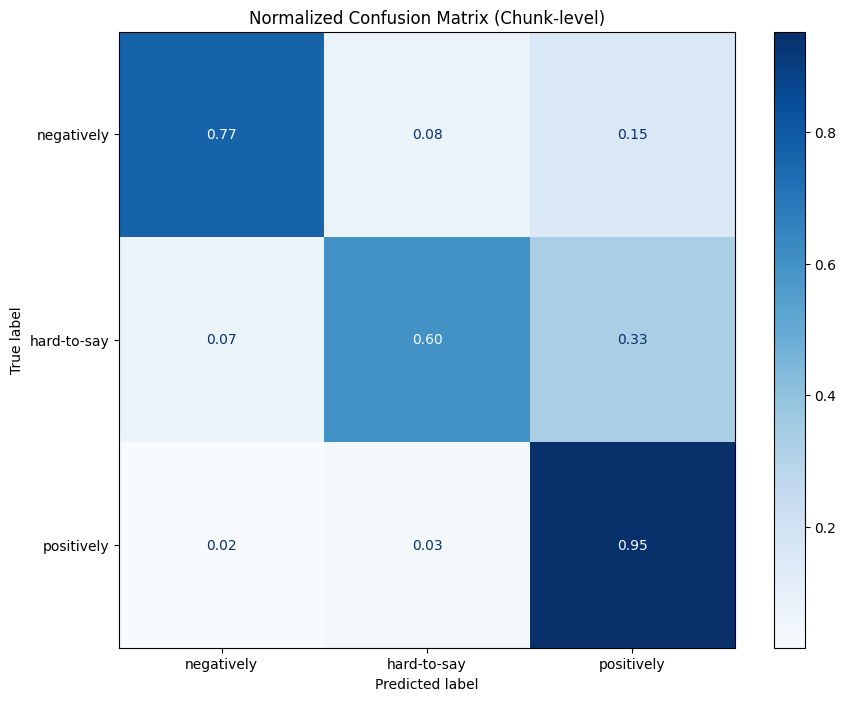

In [15]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [17]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Content_specific/Industry_chunks_topics.parquet")

In [20]:
print(df_ai_impact.shape)
df_ai_impact['topic'].value_counts()    

(3426, 8)


,count
topic,
0,1338
1,1064
2,1024


In [21]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/3426 [00:00<?, ? examples/s]

In [22]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(3426, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,265_0_0_0_0,https://www.bizcommunity.com/Article/196/778/2...,2023-11-22,#Trends: DMOs embrace AI and prioritise digita...,2,#Trends: DMOs embrace AI and prioritise digita...,positively,0.985797,0.006800,0.007403,0.985797
1,511_1_0_0_0,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,Email Address\n *5#000000#FFFFFFHOME>News>arti...,positively,0.964200,0.020768,0.015032,0.964200
2,511_1_0_0_1,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,As the senators explained:The EDGE Shelf helps...,hard-to-say,0.476019,0.210769,0.476019,0.313212
3,511_3_0_0_0,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,Our work is licensed under Creative Commons (C...,positively,0.981890,0.008130,0.009980,0.981890
4,511_3_0_0_1,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,As the senators explained:The EDGE Shelf helps...,hard-to-say,0.458492,0.243563,0.458492,0.297946


/tmp/ipykernel_7263/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


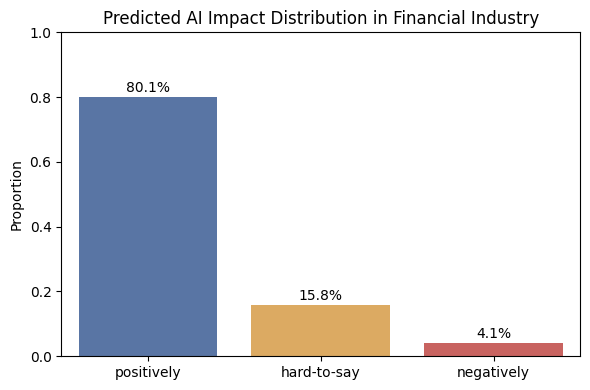

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
df_ai_impact_pred.to_parquet(f"{DATA_DIR}/Content_specific/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [3]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_classifier_predictions.parquet")
print(len(df_ai_impact_pred))
df_ai_impact_pred.head(2)

3426


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,265_0_0_0_0,https://www.bizcommunity.com/Article/196/778/2...,2023-11-22,#Trends: DMOs embrace AI and prioritise digita...,2,#Trends: DMOs embrace AI and prioritise digita...,positively,0.985797,0.006800,0.007403,0.985797
1,511_1_0_0_0,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,Email Address\n *5#000000#FFFFFFHOME>News>arti...,positively,0.964200,0.020768,0.015032,0.964200


#### Positive impact

In [4]:
df_ai_impact_ner_sample_pos = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(500, random_state=38).reset_index(drop=True)

In [5]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [6]:
pos_entity_system_msg = """\
You are an information extraction system for consumer economy industry news articles.

The user will provide a text block from a consumer economy article.
Your task is to extract only the following:

1. organizations or companies in the consumer economy ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or positive impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named organizations, companies, brands, platforms, or institutions explicitly stated in the text.

This may include:
- retail companies
- e-commerce platforms
- grocery chains
- consumer brands
- restaurants or food chains
- food delivery platforms
- travel platforms
- airlines
- hotel chains
- hospitality companies
- online marketplaces
- logistics and delivery companies
- technology companies providing AI tools for consumer businesses

Examples:
- Amazon
- Walmart
- Target
- Costco
- Shopify
- Instacart
- Uber Eats
- DoorDash
- Starbucks
- McDonald's
- Airbnb
- Booking.com
- Expedia
- Marriott
- Hilton
- Delta Air Lines
- Nike
- Coca-Cola
- OpenAI
- Google
- Microsoft

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies, operational tools, or positive impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:
- generative AI
- large language models
- machine learning
- recommendation systems
- personalized product recommendations
- dynamic pricing algorithms
- demand forecasting
- inventory optimization
- supply chain optimization
- logistics optimization
- AI-powered customer service
- chatbots
- automated checkout systems
- visual product search
- AI-powered marketing personalization
- fraud detection
- delivery route optimization
- travel recommendation engines
- booking optimization
- productivity improvement
- cost reduction
- operational efficiency
- workflow automation

## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the retailer”, “the company”, “the platform”, or “the restaurant” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [7]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [8]:
train_ai_positive_impact_ner = []

for idx, row in df_ai_impact_ner_sample_pos.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=pos_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_positive_impact_ner.append(result)
    
df_ai_positive_impact_ner_result = pd.DataFrame(train_ai_positive_impact_ner)

In [9]:
df_ai_positive_impact_ner_result

,organizations,ai_technologies_or_mechanisms,api_status,chunk_uid,title,text,pred_label,topic
0,"[Nvidia, National Retail Federation]","[artificial intelligence, AI applications, Ret...",success,95739_0_0_0_1,Nvidia unveils new AI workflows to help the re...,The workflows are built on Nvidia’s Metropolis...,positively,0
1,"[NielsenIQ, ciValue]","[advanced AI technology, personalization capab...",success,93695_0_0_0_0,NielsenIQ Acquires Retail AI Platform Provider...,NielsenIQ Acquires Retail AI Platform Provider...,positively,0
2,"[Amazon, Spotify, Netflix]","[artificial intelligence, machine learning, pe...",success,127723_0_0_0_0,The importance of AI categories in ecommerce -...,The importance of AI categories in ecommerce -...,positively,0
3,"[Fast Company, Expedia, Kayak, Google, Instagr...","[AI, AI tool, streamline bookings, recommendat...",success,41780_0_0_0_0,Don’t worry about AI ruining travel—social med...,Don’t worry about AI ruining travel—social med...,positively,2
4,"[Reventals, TapGoods, Inc]",[],success,110422_0_0_0_2,Reventals Launches Evie -- the First AI Assist...,"Once the event package is finalized, customers...",positively,2
...,...,...,...,...,...,...,...,...
495,[Canary Technologies],"[AI Voice platform, AI-powered hotel assistant...",success,28279_0_0_0_0,Canary Technologies Launches AI Voice Platform...,Canary Technologies Launches AI Voice Platform...,positively,2
496,"[Domino's, Yum! Brands, Pizza Hut, Dragontail ...","[computer vision, quality checking, product qu...",success,2981_0_0_0_2,4 successful attempts to use AI in restaurants...,The system used computer vision—cameras that t...,positively,1
497,"[Google, Google Bard, Google Sheets, Google Ma...","[generative AI, large language models, AI imag...",success,68173_0_1_0_2,I used Google Bard to plan the perfect vacatio...,5. Get a full itinerary in Google Sheets\n(Ima...,positively,2
498,"[OpenAI, Airbnb]",[],success,970_0_0_0_1,'Shut Up and Follow the Advice:' Airbnb's Bria...,Here’s what you’re screwing up. Here’s what yo...,positively,2


In [10]:
df_ai_positive_impact_ner_result.to_parquet(f"{DATA_DIR}/Content_specific/consumer_ai_positiveimpact_ner.parquet", index=False)

##### Organization 

In [ ]:
# df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_positiveimpact_ner.parquet")

In [11]:
df_posorg_long = (
    df_ai_positive_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(1076, 2)
(212, 2)


,entity_raw,raw_count
0,Google,55
1,Microsoft,31
2,Walmart,28
3,OpenAI,27
4,Google Cloud,23
...,...,...
207,Del Taco,2
208,7-Eleven,2
209,Destination AI,2
210,AWS,2


In [12]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

"- (Google, 55)\n- (Microsoft, 31)\n- (Walmart, 28)\n- (OpenAI, 27)\n- (Google Cloud, 23)\n- (Amazon, 23)\n- (Wendy's, 19)\n- (McDonald's, 19)\n- (ChatGPT, 18)\n- (Expedia, 16)\n- (Airbnb, 14)\n- (Shopify, 11)\n- (IBM, 10)\n- (Taco Bell, 9)\n- (Instacart, 9)\n- (Booking.com, 8)\n- (Standard AI, 7)\n- (Instagram, 7)\n- (eBay, 7)\n- (TikTok, 6)\n- (Meta, 6)\n- (Mindtrip, 5)\n- (Booking Holdings, 5)\n- (CNBC, 5)\n- (Carl's Jr., 5)\n- (YouTube, 5)\n- (Product Hunt, 5)\n- (Kayak, 5)\n- (Chipotle, 5)\n- (Yum!, 4)\n- (Emirates, 4)\n- (PYMNTS, 4)\n- (Macy's, 4)\n- (Hardee's, 4)\n- (Forbes, 4)\n- (Costco, 4)\n- (Apple, 4)\n- (Salesforce, 4)\n- (Priceline, 4)\n- (Miso Robotics, 4)\n- (Perplexity, 4)\n- (NVIDIA, 4)\n- (Checkers & Rally's, 4)\n- (Skift, 4)\n- (Sam's Club, 4)\n- (SAP SE, 4)\n- (Ralph Lauren, 3)\n- (Salesforce.com Inc., 3)\n- (Arabian Travel Market, 3)\n- (Google Flights, 3)\n- (Gray Media Group, 3)\n- (IBM Watson, 3)\n- (Marriott, 3)\n- (CKE Restaurants, 3)\n- (Canary Technologies,

In [13]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from Consumer Economy Industries-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - consumer_economy_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 Consumer Economy Industries companies
   - Top 10 AI companies

Rules:
- Be conservative when merging.
- Do not merge different companies.
- consumer_economy_company should be companies or organizations primarily in the Consumer Economy Industries,
  such as retail, e-commerce, consumer goods, food and beverage, and other consumer-focused sectors.
- ai_company should be companies primarily in AI or companies with a strong AI-product focus.
- Use counts exactly as given.
- Unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "consumer_economy_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "consumer_economy_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["consumer_economy_top10", "ai_top10"],
    "additionalProperties": False
}

In [14]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [16]:
industry_company_top10_pos = pd.DataFrame(result_posorg["consumer_economy_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Media & Creative Industry Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Media & Creative Industry Top 10


,canonical_name,total_count,source_raw_names
0,Walmart,32,"[Walmart, Sam's Club]"
1,Amazon,25,"[Amazon, Amazon.com Inc.]"
2,McDonald's,19,[McDonald's]
3,Wendy's,19,[Wendy's]
4,Expedia,19,"[Expedia, Expedia Group]"
5,Airbnb,14,[Airbnb]
6,Shopify,11,[Shopify]
7,Booking Holdings,13,"[Booking.com, Booking Holdings, Booking Holdin..."
8,Yum! Brands,16,"[Yum!, Yum! Brands, Taco Bell, KFC, Pizza Hut]"
9,Instacart,9,[Instacart]


AI Top 10


,canonical_name,total_count,source_raw_names
0,Google,62,"[Google, Google Cloud, Google Flights, Google ..."
1,Microsoft,33,"[Microsoft, Microsoft Corp.]"
2,OpenAI,27,[OpenAI]
3,ChatGPT,18,[ChatGPT]
4,IBM,15,"[IBM, IBM Watson, IBM Corporation, Internation..."
5,NVIDIA,8,"[NVIDIA, NVIDIA Corp., Nvidia]"
6,Salesforce,7,"[Salesforce, Salesforce.com Inc.]"
7,Meta,9,"[Meta, Facebook, Instagram, WhatsApp, Facebook..."
8,Apple,6,"[Apple, Apple Store]"
9,Anthropic,3,[Anthropic]


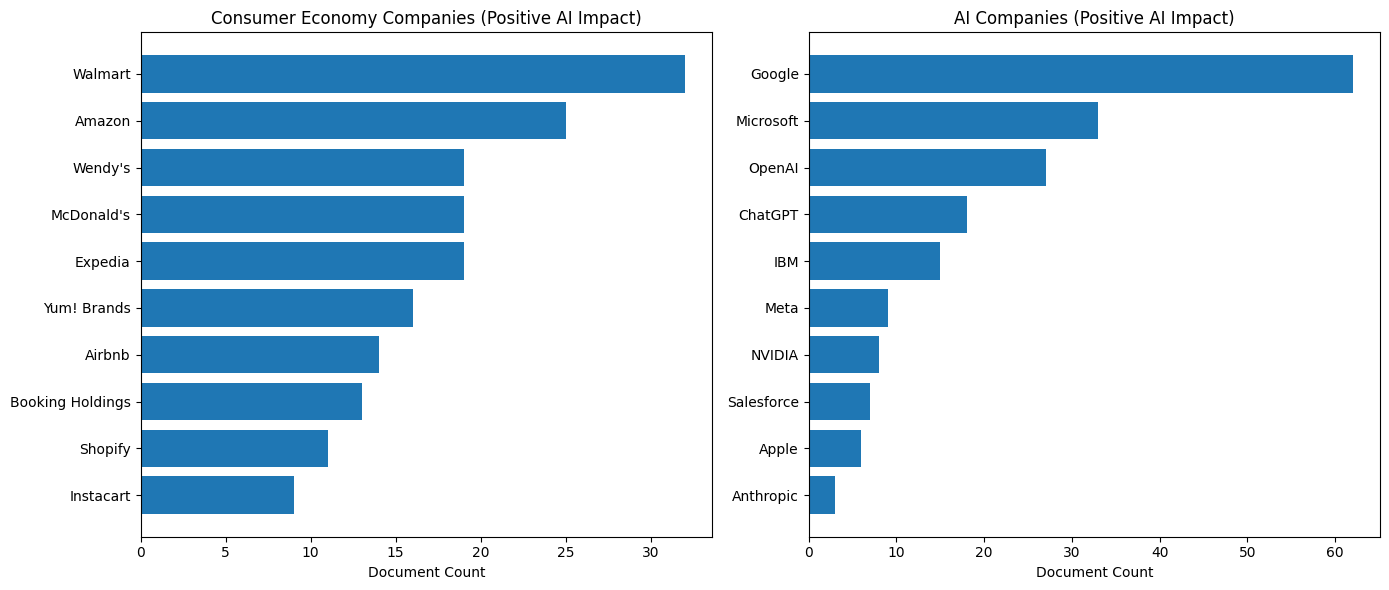

In [17]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Consumer Economy Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [18]:
df_posmech_long = (
    df_ai_positive_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(1735, 2)
(197, 2)


,entity_raw,raw_count
0,generative AI,81
1,artificial intelligence,61
2,AI,59
3,machine learning,38
4,chatbots,23
...,...,...
192,ease team members' workloads,2
193,AI-powered review summaries,2
194,visual search,2
195,Natural Language Processing,2


In [19]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

"- (generative AI, 81)\n- (artificial intelligence, 61)\n- (AI, 59)\n- (machine learning, 38)\n- (chatbots, 23)\n- (ChatGPT, 21)\n- (AI chatbot, 14)\n- (AI tools, 13)\n- (automation, 12)\n- (AI agents, 12)\n- (agentic AI, 11)\n- (computer vision, 11)\n- (large language models, 11)\n- (chatbot, 11)\n- (operational efficiency, 11)\n- (personalized recommendations, 11)\n- (inventory management, 10)\n- (AI technology, 9)\n- (Artificial Intelligence, 8)\n- (AI models, 8)\n- (AI assistant, 7)\n- (dynamic pricing, 7)\n- (AI tool, 7)\n- (AI-powered customer service, 6)\n- (AI chatbots, 6)\n- (personalization, 6)\n- (predictive analytics, 6)\n- (virtual assistants, 5)\n- (GenAI, 5)\n- (AI-powered search tool, 5)\n- (AI-powered tools, 5)\n- (AI travel assistant, 5)\n- (natural language processing, 5)\n- (customer service, 5)\n- (personalized experiences, 5)\n- (search, 5)\n- (product recommendations, 5)\n- (streamline operations, 5)\n- (voice AI, 4)\n- (Generative AI, 4)\n- (efficiency, 4)\n- (A

In [20]:
posmech_top_system_msg = """\
You are an AI technology and Consumer Economy Industries impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from Consumer Economy Industries-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_media_creative_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI media & creative industry mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches. Don't take AI and artificial intelligence as core AI technologies, but include specific technologies.



### ai_consumer_economy_mechanism
Applications, production workflows, or industry mechanisms through which AI affects the Consumer Economy Industries.



### other
Anything vague, unclear, or not clearly an AI technology or media/creative industry mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_media_creative_mechanism when the media/creative industry context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [21]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [22]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,92,"[generative AI, GenAI, Generative AI, generati..."
1,machine learning,43,"[machine learning, ML, Machine Learning]"
2,large language models,36,"[ChatGPT, large language models, GPT-4, GPT-3...."
3,computer vision,13,"[computer vision, Computer Vision]"
4,natural language processing,10,"[natural language processing, natural language..."
5,conversational AI,4,[conversational AI]
6,voice AI,4,"[voice AI, Voice AI]"
7,predictive analytics,6,[predictive analytics]
8,robotics,3,[robotics]
9,facial recognition,2,[facial recognition]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,chatbots,57,"[chatbots, AI chatbot, chatbot, AI chatbots, A..."
1,AI assistants,25,"[AI assistant, virtual assistants, AI travel a..."
2,personalized recommendations,25,"[personalized recommendations, product recomme..."
3,AI-powered customer service,11,"[AI-powered customer service, customer service..."
4,inventory management,14,"[inventory management, inventory optimization]"
5,dynamic pricing,9,"[dynamic pricing, price optimization, compare ..."
6,demand forecasting,6,"[demand forecasting, forecast demand, forecast..."
7,autonomous checkout,6,"[autonomous checkout platform, autonomous chec..."
8,AI-powered search,9,"[AI-powered search tool, search, AI-powered se..."
9,workflow automation,9,"[automation, workflow automation, AI automatio..."


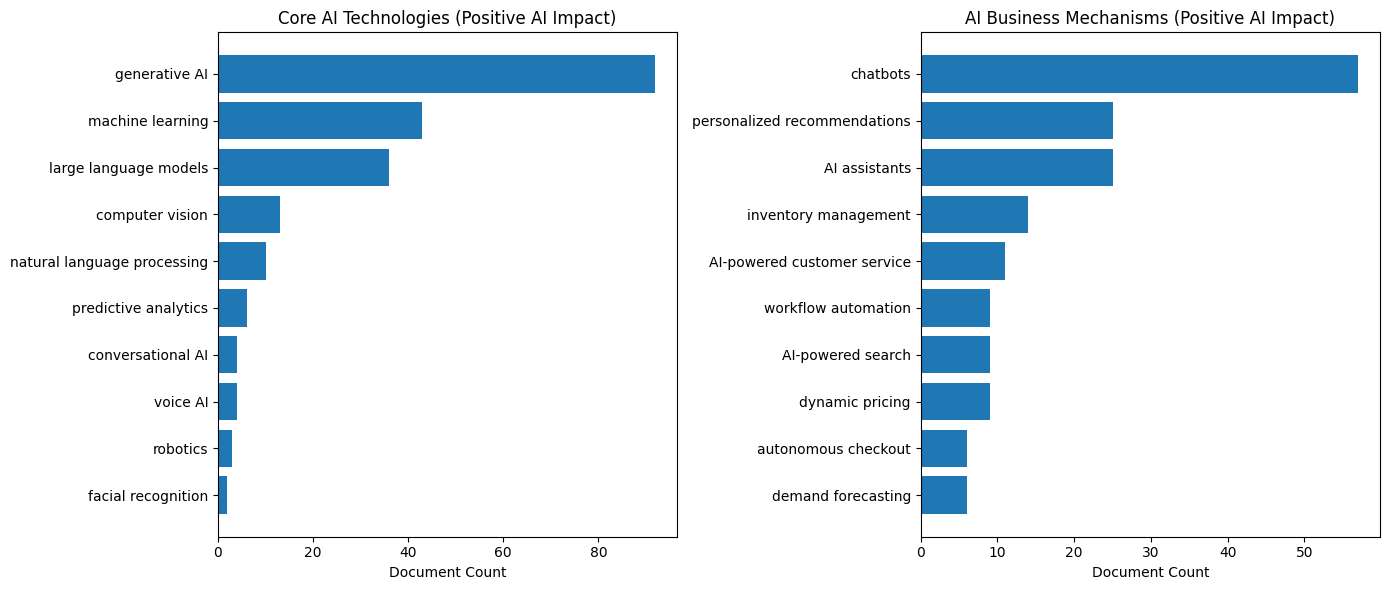

In [23]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [25]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

141


In [30]:
neg_entity_system_msg = """\
You are an information extraction system for consumer economy industry news articles.

The user will provide a text block from a consumer economy article.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or institutions in the consumer economy ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS
Extract named consumer economy organizations, companies, or institutions explicitly stated in the text.

This may include:
- retail companies
- e-commerce platforms
- grocery chains
- restaurants or food service chains
- food delivery platforms
- travel platforms
- airlines
- hotel chains
- hospitality companies
- online marketplaces
- consumer brands
- logistics and delivery companies
- regulators or consumer protection institutions



## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:

- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE consumer economy impact mechanisms explicitly mentioned in the text



## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides in the consumer economy industries.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the studio”, “the company”, “creators”, or “the platform” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [31]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

In [32]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Content_specific/consumer_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [33]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(168, 2)
(54, 2)


,entity_raw,raw_count
0,McDonald's,27
1,Google,13
2,Walmart,12
3,Instacart,11
4,Wendy's,10
5,Taco Bell,8
6,Starbucks,6
7,Costco,5
8,Federal Trade Commission,5
9,IBM,5


In [34]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (McDonald's, 27)\n- (Google, 13)\n- (Walmart, 12)\n- (Instacart, 11)\n- (Wendy's, 10)\n- (Taco Bell, 8)\n- (Starbucks, 6)\n- (Costco, 5)\n- (Federal Trade Commission, 5)\n- (IBM, 5)\n- (Kroger, 5)\n- (Microsoft, 5)\n- (Target, 5)\n- (TikTok, 5)\n- (Reuters, 5)\n- (Safeway, 5)\n- (KFC, 4)\n- (Albertsons, 3)\n- (Consumer Reports, 3)\n- (New York Times, 2)\n- (Nasdaq, 2)\n- (New York Post, 2)\n- (Meta, 2)\n- (National Retail Federation, 2)\n- (Chipotle, 2)\n- (Casa Azure, 2)\n- (Casa Oceana, 2)\n- (Chef Robotics, 2)\n- (Dunkin' Donuts, 2)\n- (KOA, 2)\n- (Indian Railways, 2)\n- (Insider, 2)\n- (Sonic, 2)\n- (The LaLiT Golf & Spa Resort Goa, 2)\n- (OpenAI, 2)\n- (BBC, 2)\n- (Apple, 2)\n- (Amazon, 2)\n- (CNN, 2)\n- (CBS News, 2)\n- (Restaurant Business, 2)\n- (Pew Research, 2)\n- (Sprouts Farmers Market, 2)\n- (The Nation, 2)\n- (Villa Oceania, 2)\n- (Taj Fort Aguada Resort & Spa, 2)\n- (The Wall Street Journal, 2)\n- (Veesion, 2)\n- (W Goa, 2)\n- (WSJ, 2)\n- (Fox News, 2)\n- (FTC, 2)\n- 

In [35]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [37]:
industry_company_top10_neg = pd.DataFrame(result_negorg["consumer_economy_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Consumer Economy Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Consumer Economy Top 10


,canonical_name,total_count,source_raw_names
0,McDonald's,27,[McDonald's]
1,Walmart,12,[Walmart]
2,Instacart,11,[Instacart]
3,Wendy's,10,[Wendy's]
4,Taco Bell,8,[Taco Bell]
5,Starbucks,6,[Starbucks]
6,Costco,5,[Costco]
7,Kroger,5,[Kroger]
8,Target,5,[Target]
9,Safeway,5,[Safeway]


AI Top 10


,canonical_name,total_count,source_raw_names
0,Google,13,[Google]
1,Microsoft,5,[Microsoft]
2,Meta,2,[Meta]
3,OpenAI,2,[OpenAI]
4,Apple,2,[Apple]
5,Amazon,2,[Amazon]
6,IBM,5,[IBM]
7,TikTok,5,[TikTok]
8,Chef Robotics,2,[Chef Robotics]
9,Veesion,2,[Veesion]


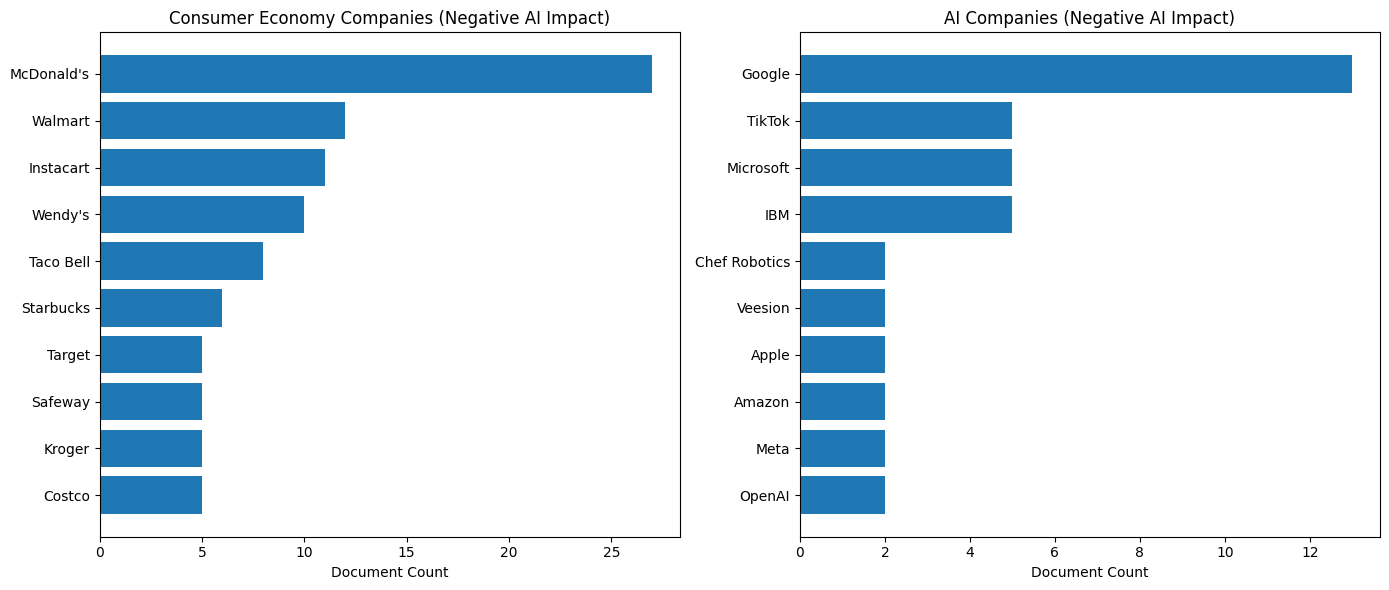

In [38]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Consumer Economy ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Consumer Economy Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [39]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(522, 2)
(55, 2)


,entity_raw,raw_count
0,ChatGPT,18
1,AI,17
2,artificial intelligence,8
3,AI chatbot,6
4,AI systems,5
5,AI hallucinations,5
6,AI chatbots,4
7,chatbot,4
8,generative AI,4
9,AI drive-thru ordering,3


In [40]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (ChatGPT, 18)\n- (AI, 17)\n- (artificial intelligence, 8)\n- (AI chatbot, 6)\n- (AI systems, 5)\n- (AI hallucinations, 5)\n- (AI chatbots, 4)\n- (chatbot, 4)\n- (generative AI, 4)\n- (AI drive-thru ordering, 3)\n- (AI bots, 3)\n- (AI distortions, 3)\n- (AI lies, 3)\n- (AI system, 3)\n- (biased content, 3)\n- (dynamic pricing, 3)\n- (AI drive-thru ordering system, 2)\n- (AI price-adjusting tool, 2)\n- (AI drive-thrus, 2)\n- (Generative AI, 2)\n- (AI tools, 2)\n- (AI robot arms, 2)\n- (AI-generated content, 2)\n- (AI fails, 2)\n- (Hapsburg AI, 2)\n- (AI pricing tests, 2)\n- (AI pricing tool, 2)\n- (AI hallucination, 2)\n- (AI ordering system, 2)\n- (AI hiring chatbot, 2)\n- (AI program that Google uses to summarize its search results, 2)\n- (AI subject to human biases, 2)\n- (AI's inability to understand relative value of money, 2)\n- (AI not respecting copyrights, 2)\n- (algorithmic pricing, 2)\n- (AI lacking accountability, 2)\n- (AI technology, 2)\n- (AI's limitations, 2)\n- (AI vo

In [45]:
neg_mech_top_system_msg = """\
You are an AI technology and Consumer Economy Industries impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from Consumer Economy Industries-related AI news.

Your tasks:

1. Merge or sumarize raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_media_creative_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI Consumer Economy industry mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.



### ai_media_creative_mechanism
Applications, industry impacts, or structural mechanisms through which AI negatively affects the Consumer Economy Industries.

Focus on negative impact mechanisms, risks, harms, and downsides in media and creative sectors.



### other
Anything vague, unclear, or not clearly an AI technology or media/creative industry mechanism.


Rules:
- Merge or summarize only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_media_creative_mechanism when the media or creative industry context is clear.

Note on classification:
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.
- AI models, AI systems, and AI tools should generally be grouped under generative AI if they refer to generative AI systems.
- AI chatbots and AI bots should be grouped under large language models when they are LLM-based systems.
- Avoid creating overly generic categories when a more specific AI technology category already exists.


Return valid JSON only.
"""

In [46]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0.3,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat",
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [48]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])

print("Core AI Technology Top 10")
show_full(technology_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,large language models,36,"[ChatGPT, AI chatbot, AI chatbots, chatbot, AI bots, chatbots, AI hiring chatbot]"
1,generative AI,15,"[generative AI, AI systems, AI system, Generative AI, AI tools, AI models, AI applications, AI technology]"
2,machine learning,10,"[machine learning, AI, artificial intelligence, algorithms, models]"
3,computer vision,4,"[computer vision systems, facial recognition]"
4,robotics,4,"[AI robot arms, robots]"
5,big data,2,[big data]
6,Hapsburg AI,2,[Hapsburg AI]
7,voice ordering technology,2,[voice-ordering technology]
8,self-checkout kiosks,2,[self-checkout kiosks]
9,AI program that Google uses to summarize its search results,2,[AI program that Google uses to summarize its search results]


In [49]:
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])
print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,AI hallucinations,7,"[AI hallucinations, AI hallucination, generate..."
1,AI distortions,6,"[AI distortions, AI lies, AI fails]"
2,AI drive-thru ordering errors,5,"[AI drive-thru ordering, AI drive-thru orderin..."
3,AI pricing manipulation,5,"[dynamic pricing, AI price-adjusting tool, AI ..."
4,biased AI content,3,"[biased content, AI subject to human biases]"
5,AI-generated content copyright issues,2,"[AI-generated content, AI not respecting copyr..."
6,AI lacking accountability,2,[AI lacking accountability]
7,AI's limitations in economic understanding,2,[AI's inability to understand relative value o...
8,AI adoption risks,2,[AI adoption]
9,feedback loops in AI systems,2,[feedback loop]


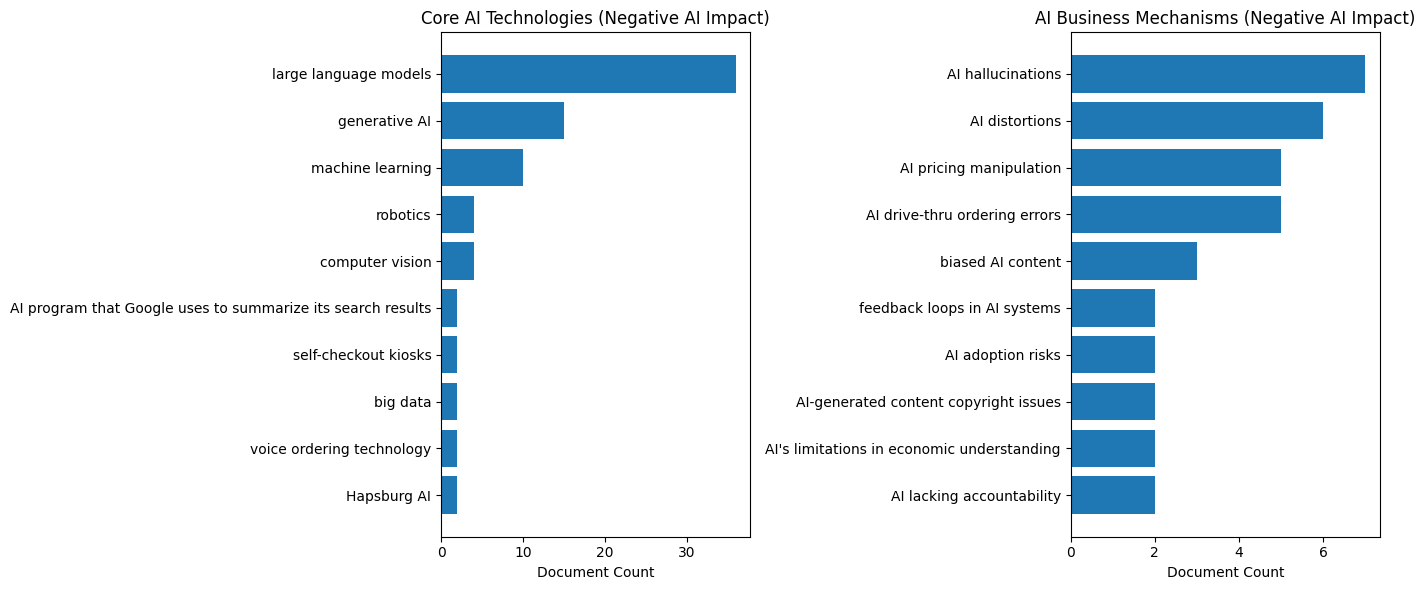

In [50]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [51]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Content_specific/content_ai_impact_classifier_predictions.parquet")

#### Topic Aggregation

In [56]:
Industry_topics = pd.read_csv(f"{DATA_DIR}/Content_specific/Content_topics.csv")[['Topic','Representation','Representative_Docs']].copy()
Industry_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Content_specific/Industry_chunks_topics.parquet")

In [57]:
Industry_topics

,Topic,Representation,Representative_Docs
0,0,"['shopify', 'retail market', 'retailer', 'inte...",['Walmart experiments with AI to enhance custo...
1,1,"['drive-thru', 'wendy', 'cooking', 'fast food'...",['Wendy’s to test AI chatbot at Ohio drive-thr...
2,2,"['expedia', 'itinerary', 'travel industry', 't...",['Larry Magid: Using AI and apps for summer tr...


In [58]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in Industry_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

Industry_topics["topic_summary"] = summaries
show_full(Industry_topics[["Topic", "Representation", "topic_summary"]])

,Topic,Representation,topic_summary
0,0,"['shopify', 'retail market', 'retailer', 'intelligence retail', 'in-store', 'shopping experience', 'online shopping', 'shopper', 'shopping experiences', 'retail industry']",This topic is about using technology like AI to improve both online and in-store retail shopping experiences.
1,1,"['drive-thru', 'wendy', 'cooking', 'fast food', 'taco', 'grill', 'chipotle', 'taco bell', 'drive-thrus', 'steak']",Wendy's is testing an AI chatbot to automate drive-thru orders at its fast-food restaurants.
2,2,"['expedia', 'itinerary', 'travel industry', 'travel planning', 'skift', 'travelingwiki', 'travellers', 'online travel', 'traveler', 'planner']",AI and apps for travel planning and itinerary creation.


In [61]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,265_0_0_0_0,https://www.bizcommunity.com/Article/196/778/2...,2023-11-22,#Trends: DMOs embrace AI and prioritise digita...,2,#Trends: DMOs embrace AI and prioritise digita...,positively,0.985797,0.006800,0.007403,0.985797,265
1,511_1_0_0_0,https://www.commondreams.org/news/kroger-ai,2024-08-09,'Corporate Greed Is Out of Control': Warren Sl...,0,Email Address\n *5#000000#FFFFFFHOME>News>arti...,positively,0.964200,0.020768,0.015032,0.964200,511


In [62]:
df_ai_impact_pred['topic'].value_counts()

topic
0    1338
1    1064
2    1024
Name: count, dtype: int64

In [64]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)

display(aiimpact_topic_label_doc_prop_pct)

# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)
show_full(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively
0,0,112,27,556
1,1,131,48,376
2,2,114,25,383


pred_label,topic,hard-to-say,negatively,positively
0,0,16.12%,3.88%,80.0%
1,1,23.6%,8.65%,67.75%
2,2,21.84%,4.79%,73.37%


pred_label,topic,hard-to-say,negatively,positively,impact_score
0,0,0.161151,0.038849,0.800000,0.761151
1,1,0.236036,0.086486,0.677477,0.590991
2,2,0.218391,0.047893,0.733716,0.685824


In [66]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.77, 0.08, 0.15],
    [0.07, 0.60, 0.33],
    [0.02, 0.03, 0.95]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
show_full(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,0,0.229226,0.009850,0.760924,0.751074
1,1,0.355771,0.064931,0.579298,0.514368
2,2,0.329173,0.015245,0.655582,0.640336


#### Time Aggregation

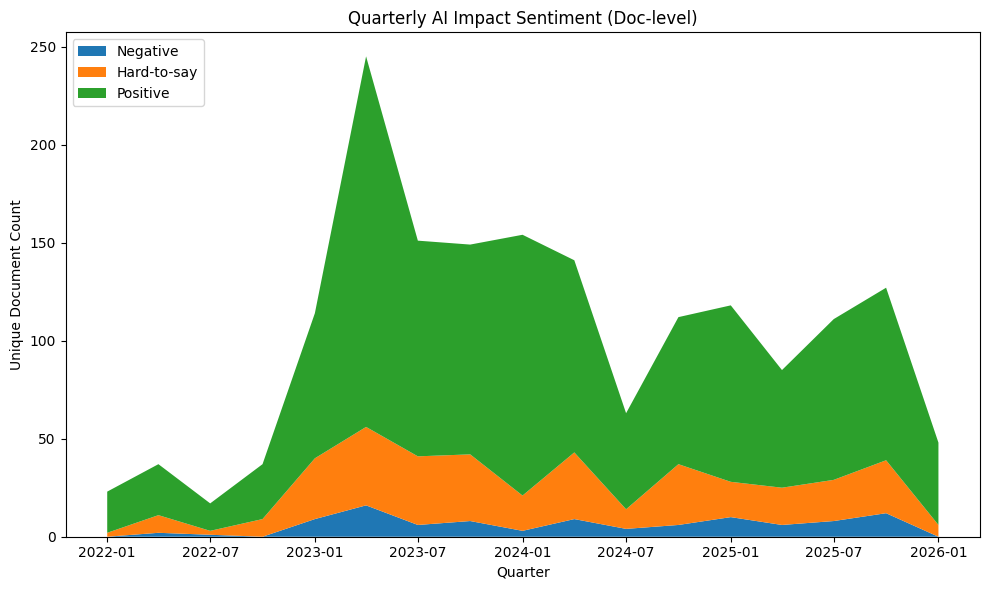

In [67]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

pred_label,hard-to-say,negatively,positively
quarter,,,
2022-01-01,0.086957,0.000000,0.913043
2022-04-01,0.243243,0.054054,0.702703
2022-07-01,0.117647,0.058824,0.823529
2022-10-01,0.243243,0.000000,0.756757
2023-01-01,0.271930,0.078947,0.649123
2023-04-01,0.163265,0.065306,0.771429
2023-07-01,0.231788,0.039735,0.728477
2023-10-01,0.228188,0.053691,0.718121
2024-01-01,0.116883,0.019481,0.863636


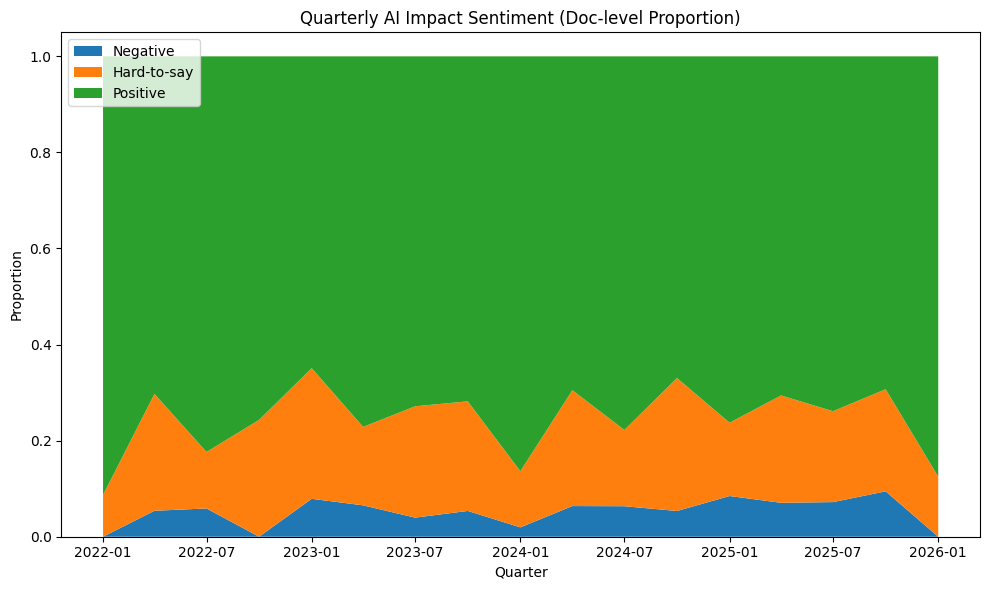

In [68]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
display(quarter_sent_prop)

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()